# Wind Event in Jun 2026 and Jul 2026 at Juan de Fuca Strait

SalishSeaCast results show an oxygen-depletion around Juan de Fuca in July 2026, possibly caused by coastal upwelling.

## 2026 Wind Event

### Time Series

In [ ]:
# Path and location

# location: 48.5, 125.00

# HRDPS path: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_yYYYYmMMdDD.nc'
# Example: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2026m07d20.nc'
# Variables: 'u_wind', 'u_wind'
# Dimension: 'time_counter', 'nav_lat', 'nav_lon'

In [ ]:

"""
wind_NW45 > 0 : wind vector points toward NW
wind_NW45 < 0 : wind vector points toward SE
"""

from pathlib import Path
from datetime import datetime
import re

import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# User settings
# ============================================================

TARGET_LAT = 48.5
TARGET_LON = -125.0

START_DATE = pd.Timestamp("2026-06-01")
END_DATE = pd.Timestamp.today().normalize()

HRDPS_DIR = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)

OUTPUT_CSV = Path(
    f"hrdps_wind_{TARGET_LAT:.2f}N_{abs(TARGET_LON):.2f}W_"
    f"{START_DATE:%Y%m%d}_to_{END_DATE:%Y%m%d}.csv"
)

U_NAME = "u_wind"
V_NAME = "v_wind"


# ============================================================
# Helper functions
# ============================================================

def longitude_difference(lon: np.ndarray, target_lon: float) -> np.ndarray:
    """
    Return the shortest signed longitude difference in degrees.

    This works whether longitude is represented as:
        -180 to 180
    or:
        0 to 360
    """
    return (lon - target_lon + 180.0) % 360.0 - 180.0


def find_nearest_grid_point(
    nav_lat: np.ndarray,
    nav_lon: np.ndarray,
    target_lat: float,
    target_lon: float,
) -> tuple[int, int]:
    """
    Find the nearest grid point using an approximate spherical distance.

    Returns
    -------
    j, i
        Indices of the nearest point in the two-dimensional spatial grid.
    """
    dlat = nav_lat - target_lat
    dlon = longitude_difference(nav_lon, target_lon)

    # Account approximately for longitude convergence with latitude.
    distance_squared = (
        dlat**2
        + (dlon * np.cos(np.deg2rad(target_lat)))**2
    )

    if np.all(np.isnan(distance_squared)):
        raise ValueError("All navigation-coordinate distances are NaN.")

    return np.unravel_index(
        np.nanargmin(distance_squared),
        distance_squared.shape,
    )


def date_from_filename(path: Path) -> pd.Timestamp | None:
    """
    Extract YYYY, MM and DD from a filename such as:
    hrdps_y2026m07d20.nc
    """
    match = re.search(
        r"hrdps_y(\d{4})m(\d{2})d(\d{2})\.nc$",
        path.name,
    )

    if match is None:
        return None

    year, month, day = map(int, match.groups())
    return pd.Timestamp(year=year, month=month, day=day)


def get_input_files(
    directory: Path,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> list[Path]:
    """Return existing HRDPS files within the requested date range."""
    selected_files = []

    for path in sorted(directory.glob("hrdps_y????m??d??.nc")):
        file_date = date_from_filename(path)

        if file_date is None:
            continue

        if start_date <= file_date <= end_date:
            selected_files.append(path)

    return selected_files


def identify_spatial_dimensions(
    data_array: xr.DataArray,
    nav_lat: xr.DataArray,
) -> tuple[str, str]:
    """
    Determine the two spatial dimension names.

    Usually nav_lat/nav_lon have dimensions such as:
        ('y', 'x')
    even though their variable names are nav_lat and nav_lon.
    """
    if nav_lat.ndim != 2:
        raise ValueError(
            f"Expected nav_lat to be two-dimensional, got {nav_lat.dims}."
        )

    y_dim, x_dim = nav_lat.dims

    if y_dim not in data_array.dims or x_dim not in data_array.dims:
        raise ValueError(
            f"Wind variable dimensions {data_array.dims} do not contain "
            f"navigation dimensions {(y_dim, x_dim)}."
        )

    return y_dim, x_dim


def extract_one_file(
    path: Path,
    j: int,
    i: int,
    y_dim: str,
    x_dim: str,
) -> pd.DataFrame:
    """Extract the wind time series from one daily HRDPS file."""
    with xr.open_dataset(path) as ds:
        missing = [
            name for name in (U_NAME, V_NAME, "time_counter")
            if name not in ds.variables and name not in ds.coords
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing variables/coordinates: {missing}. "
                f"Available data variables: {list(ds.data_vars)}"
            )

        indexer = {y_dim: j, x_dim: i}

        u = ds[U_NAME].isel(indexer).squeeze(drop=True)
        v = ds[V_NAME].isel(indexer).squeeze(drop=True)

        # Load before closing the NetCDF file.
        u_values = np.asarray(u.load().values).reshape(-1)
        v_values = np.asarray(v.load().values).reshape(-1)

        times = pd.to_datetime(
            np.asarray(ds["time_counter"].values).reshape(-1)
        )

    if not (len(times) == len(u_values) == len(v_values)):
        raise ValueError(
            f"Time and wind-array lengths differ in {path.name}: "
            f"time={len(times)}, u={len(u_values)}, v={len(v_values)}"
        )

    frame = pd.DataFrame(
        {
            "time": times,
            "u_wind": u_values,
            "v_wind": v_values,
        }
    )

    frame["source_file"] = path.name
    return frame


# ============================================================
# Main calculation
# ============================================================

def main() -> None:
    files = get_input_files(
        directory=HRDPS_DIR,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    if not files:
        raise FileNotFoundError(
            f"No HRDPS files were found in {HRDPS_DIR} between "
            f"{START_DATE:%Y-%m-%d} and {END_DATE:%Y-%m-%d}."
        )

    print(f"Found {len(files)} files.")
    print(f"First file: {files[0]}")
    print(f"Last file:  {files[-1]}")

    # Read the grid from the first available file.
    with xr.open_dataset(files[0]) as grid_ds:
        if "nav_lat" not in grid_ds or "nav_lon" not in grid_ds:
            raise KeyError(
                f"{files[0].name} does not contain nav_lat and nav_lon."
            )

        nav_lat_da = grid_ds["nav_lat"].squeeze()
        nav_lon_da = grid_ds["nav_lon"].squeeze()

        nav_lat = np.asarray(nav_lat_da.values)
        nav_lon = np.asarray(nav_lon_da.values)

        if nav_lat.shape != nav_lon.shape:
            raise ValueError(
                f"nav_lat shape {nav_lat.shape} differs from "
                f"nav_lon shape {nav_lon.shape}."
            )

        j, i = find_nearest_grid_point(
            nav_lat=nav_lat,
            nav_lon=nav_lon,
            target_lat=TARGET_LAT,
            target_lon=TARGET_LON,
        )

        actual_lat = float(nav_lat[j, i])
        actual_lon = float(nav_lon[j, i])

        y_dim, x_dim = identify_spatial_dimensions(
            grid_ds[U_NAME],
            nav_lat_da,
        )

    print(f"Target location:  {TARGET_LAT:.5f}, {TARGET_LON:.5f}")
    print(f"Nearest grid:    {actual_lat:.5f}, {actual_lon:.5f}")
    print(f"Grid indices:    {y_dim}={j}, {x_dim}={i}")

    daily_frames = []

    for number, path in enumerate(files, start=1):
        print(f"[{number:03d}/{len(files):03d}] Reading {path.name}")

        frame = extract_one_file(
            path=path,
            j=j,
            i=i,
            y_dim=y_dim,
            x_dim=x_dim,
        )

        daily_frames.append(frame)

    wind = pd.concat(daily_frames, ignore_index=True)

    # Restrict using actual timestamps, rather than filenames alone.
    end_exclusive = END_DATE + pd.Timedelta(days=1)

    wind = wind.loc[
        (wind["time"] >= START_DATE)
        & (wind["time"] < end_exclusive)
    ].copy()

    # Remove duplicate timestamps in case adjacent files overlap.
    wind = (
        wind.sort_values("time")
        .drop_duplicates(subset="time", keep="last")
        .reset_index(drop=True)
    )

    # Unit vector pointing toward northwest:
    #
    # eastward component = -1/sqrt(2)
    # northward component = +1/sqrt(2)
    #
    # Projection = u * e_NW + v * n_NW
    wind["wind_NW45"] = (
        -wind["u_wind"] + wind["v_wind"]
    ) / np.sqrt(2.0)

    # Opposite sign, included for convenience:
    # positive means the wind vector points toward southeast.
    wind["wind_SE45"] = -wind["wind_NW45"]

    wind["wind_speed"] = np.hypot(
        wind["u_wind"],
        wind["v_wind"],
    )

    wind["target_lat"] = TARGET_LAT
    wind["target_lon"] = TARGET_LON
    wind["grid_lat"] = actual_lat
    wind["grid_lon"] = actual_lon
    wind["grid_j"] = j
    wind["grid_i"] = i

    output_columns = [
        "time",
        "u_wind",
        "v_wind",
        "wind_speed",
        "wind_NW45",
        "wind_SE45",
        "target_lat",
        "target_lon",
        "grid_lat",
        "grid_lon",
        "grid_j",
        "grid_i",
        "source_file",
    ]

    wind.to_csv(
        OUTPUT_CSV,
        columns=output_columns,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
        float_format="%.6f",
    )

    print()
    print(f"Saved {len(wind)} records to:")
    print(OUTPUT_CSV.resolve())


if __name__ == "__main__":
    main()

读取记录数：1200
起始时间：2026-06-01 00:00:00
结束时间：2026-07-20 23:00:00
NW45 平均风速：-1.684 m/s


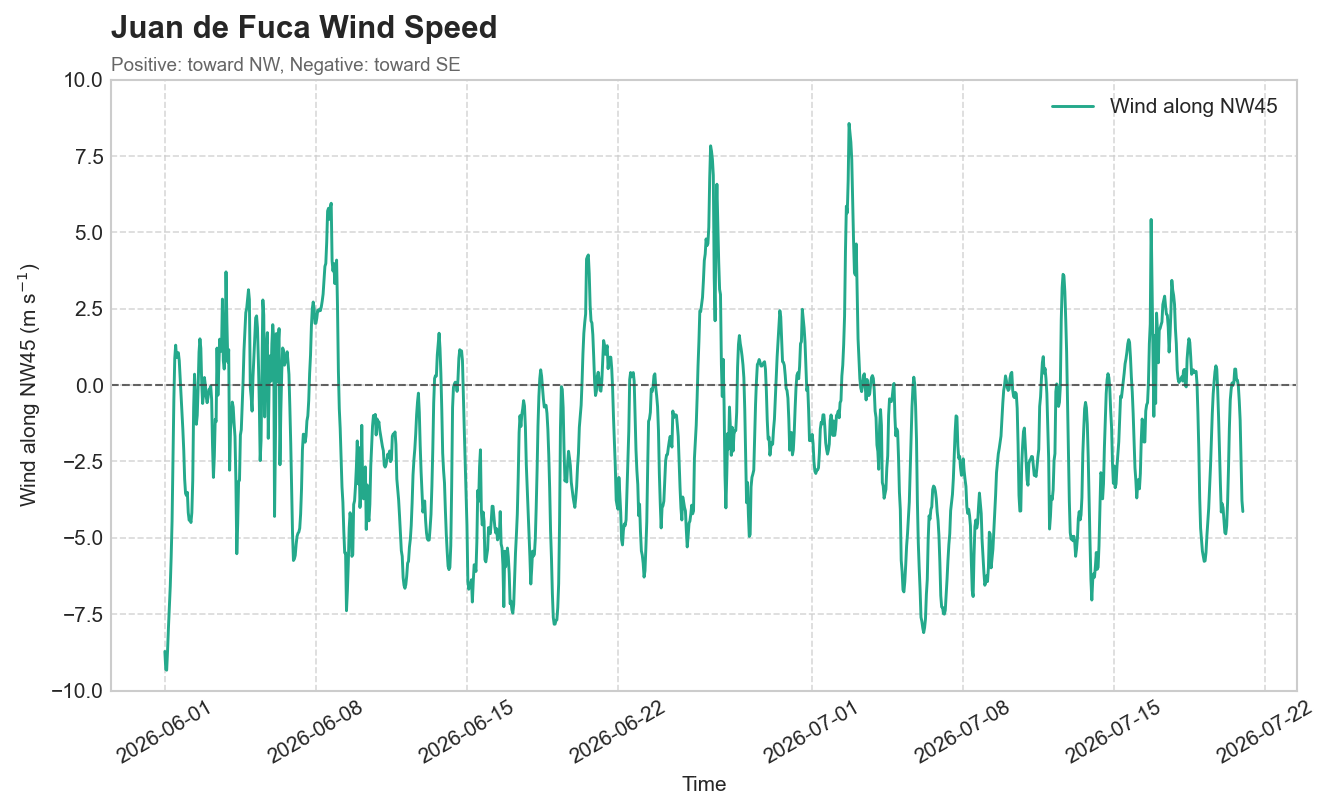

In [9]:
# Visualization

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cmocean

plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 数据读取
# -----------------------------------------------------------------------------

CSV_PATH = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/hrdps_wind_202606.csv"
)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"找不到 CSV 文件：{CSV_PATH.resolve()}")

wind = pd.read_csv(
    CSV_PATH,
    parse_dates=["time"],
)

required_columns = {
    "time",
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_NW45",
}

missing_columns = required_columns.difference(wind.columns)

if missing_columns:
    raise KeyError(
        f"CSV 缺少以下列：{sorted(missing_columns)}\n"
        f"现有列：{list(wind.columns)}"
    )

# 清理无效值并按时间排序
wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)

date = wind["time"]
wind_nw45 = wind["wind_NW45"]

print(f"读取记录数：{len(wind)}")
print(f"起始时间：{date.min()}")
print(f"结束时间：{date.max()}")
print(f"NW45 平均风速：{wind_nw45.mean():.3f} m/s")


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.plot(
    date,
    wind_nw45,
    color="#24a98b",
    lw=1.4,
    label="Wind along NW45",
)

# 零线：区分指向 NW 和指向 SE 的风
ax.axhline(
    0,
    color="0.25",
    lw=1,
    linestyle="--",
    alpha=0.8,
)

ax.tick_params(axis="x", rotation=30)

ax.set_title(
    "Juan de Fuca Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Wind along NW45 (m s$^{-1}$)")

ax.grid(
    True,
    alpha=0.75,
    linestyle="--",
)

ax.legend(
    loc="best",
    frameon=False,
)

ax.set_ylim(-10,10)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()
plt.show()

Mean NW45 Windspeed：-1.684 m/s


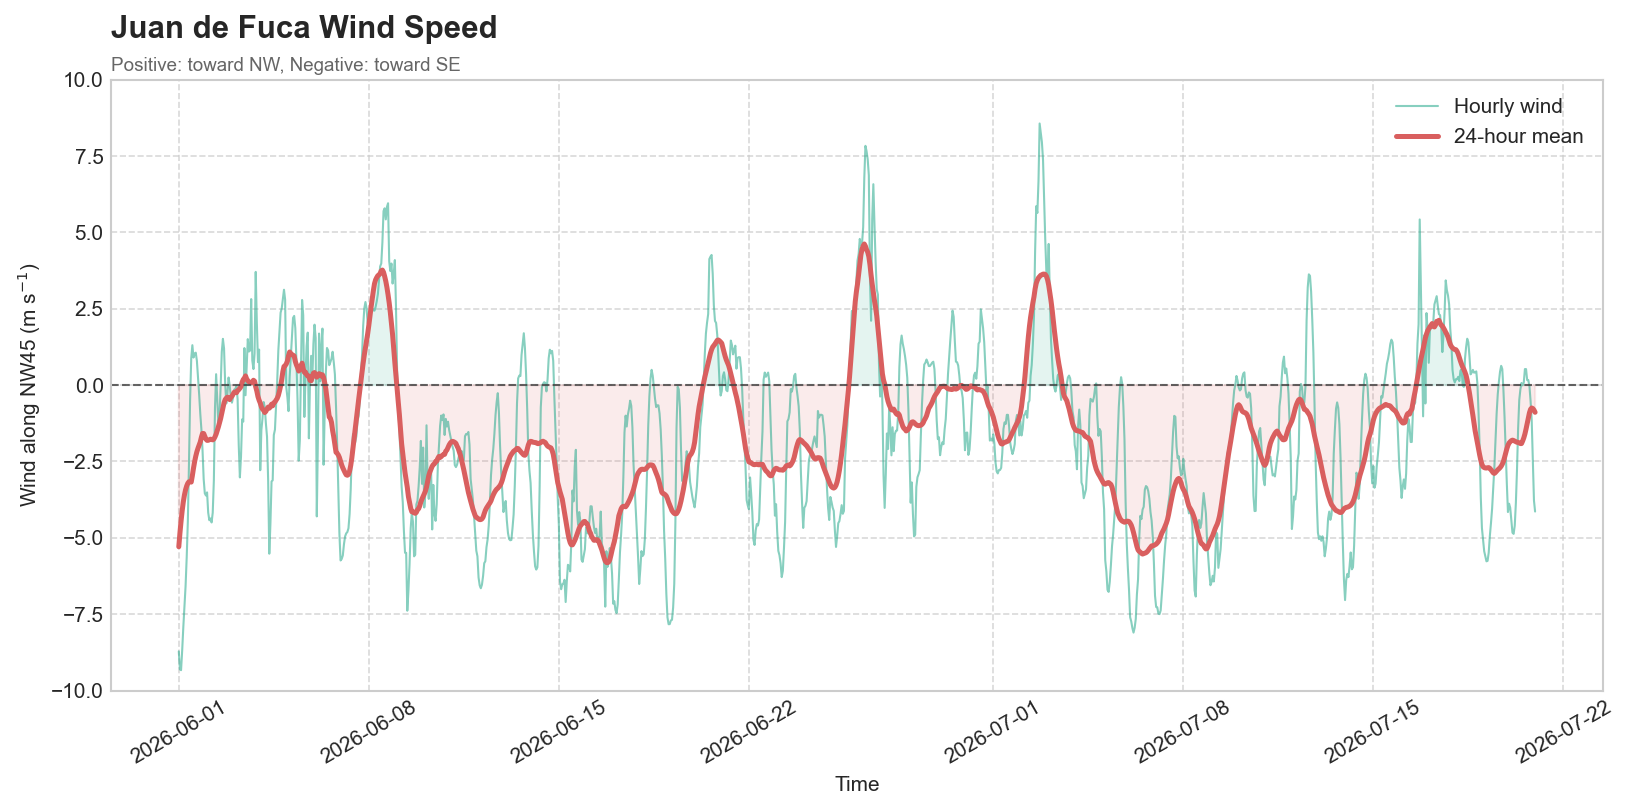

In [9]:
# 24h Smooth

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 设置
# -----------------------------------------------------------------------------

CSV_PATH = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/hrdps_wind_202606.csv"
)

ROLLING_WINDOW = "24h"


# -----------------------------------------------------------------------------
# 数据读取与处理
# -----------------------------------------------------------------------------

if not CSV_PATH.exists():
    raise FileNotFoundError(f"找不到 CSV 文件：{CSV_PATH.resolve()}")

wind = pd.read_csv(
    CSV_PATH,
    parse_dates=["time"],
)

required_columns = ["time", "wind_NW45"]
missing_columns = [
    column for column in required_columns
    if column not in wind.columns
]

if missing_columns:
    raise KeyError(
        f"CSV 缺少列：{missing_columns}；"
        f"现有列为：{list(wind.columns)}"
    )

wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)

if wind.empty:
    raise ValueError("清理后没有可用于绘图的数据。")

# 使用时间索引，使 rolling('24h') 按真实时间窗口计算
wind = wind.set_index("time")

wind["wind_NW45_24h"] = (
    wind["wind_NW45"]
    .rolling(
        ROLLING_WINDOW,
        center=True,
        min_periods=6,
    )
    .mean()
)


print(f"Mean NW45 Windspeed：{wind['wind_NW45'].mean():.3f} m/s")


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5.5),
    dpi=150,
)

# 原始风速
ax.plot(
    wind.index,
    wind["wind_NW45"],
    color="#24a98b",
    lw=1.0,
    alpha=0.55,
    label="Hourly wind",
)

# 24 小时滑动平均
ax.plot(
    wind.index,
    wind["wind_NW45_24h"],
    color="#d95f5f",
    lw=2.4,
    label="24-hour mean",
)

# 零风速参考线
ax.axhline(
    y=0,
    color="0.25",
    lw=1.0,
    linestyle="--",
    alpha=0.8,
)

# 可选：对正负方向增加淡色背景
ax.fill_between(
    wind.index,
    0,
    wind["wind_NW45_24h"],
    where=wind["wind_NW45_24h"] >= 0,
    interpolate=True,
    color="#24a98b",
    alpha=0.12,
)

ax.fill_between(
    wind.index,
    0,
    wind["wind_NW45_24h"],
    where=wind["wind_NW45_24h"] < 0,
    interpolate=True,
    color="#d95f5f",
    alpha=0.12,
)

ax.set_title(
    "Juan de Fuca Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Wind along NW45 (m s$^{-1}$)")

ax.set_ylim(-10,10)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.grid(
    True,
    alpha=0.75,
    linestyle="--",
)

ax.legend(
    loc="best",
    frameon=False,
)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()
plt.show()

### Wind Vector on Jun. 16



In [ ]:
# Path and location

# location: 48.5, 125.00
# Date: Jun.16, 2026

# HRDPS path: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_yYYYYmMMdDD.nc'
# Example: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2026m07d20.nc'
# Variables: 'u_wind', 'u_wind'
# Dimension: 'time_counter', 'nav_lat', 'nav_lon'

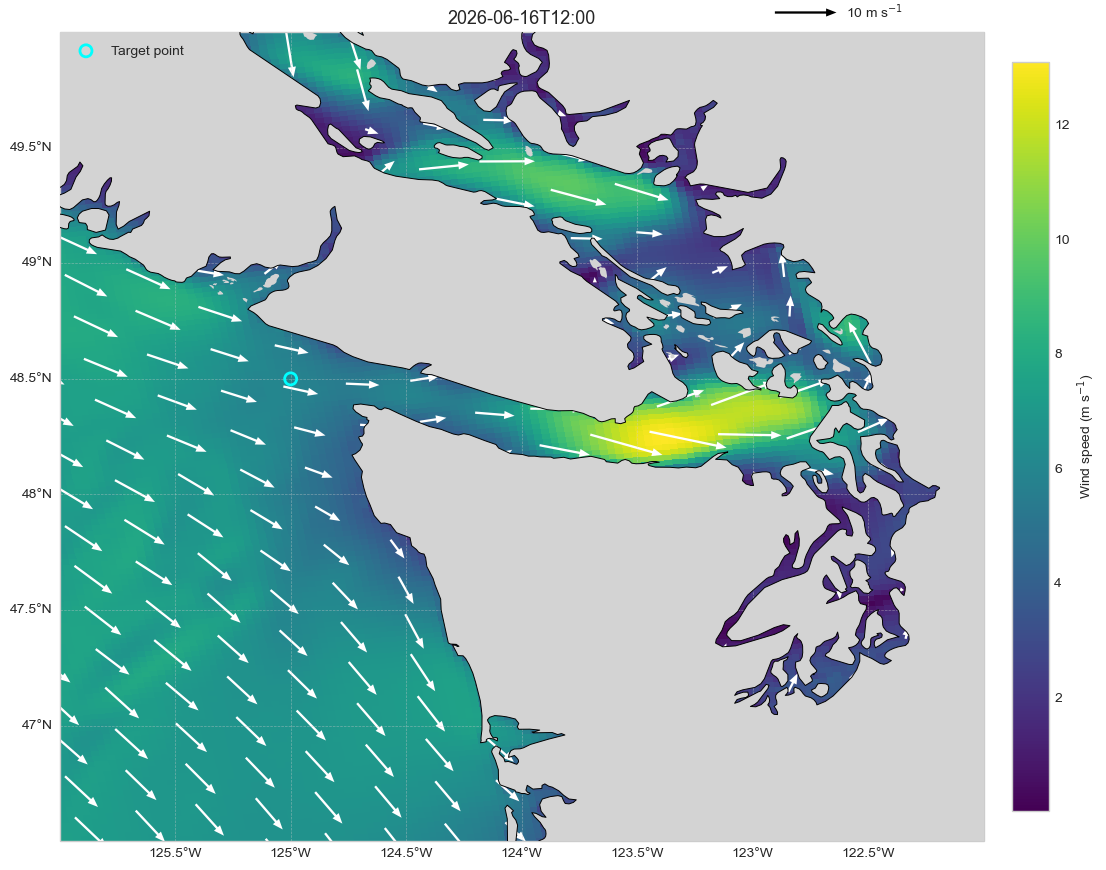

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# 基本设置
# --------------------------------------------------
date = "20260616"
time_index = 12

target_lat = 48.5
target_lon_plot = -125.0

# 风箭头抽稀
skip = 8

file_path = (
    f"/results/forcing/atmospheric/continental2.5/"
    f"nemo_forcing/hrdps_y{date[:4]}m{date[4:6]}d{date[6:]}.nc"
)

# Juan de Fuca 显示范围
lon_min = -126
lon_max = -122
lat_min = 46.5
lat_max = 50

# --------------------------------------------------
# 读取完整数据
# --------------------------------------------------
ds = xr.open_dataset(file_path)

lon = ds["nav_lon"].squeeze()
lat = ds["nav_lat"].squeeze()

u = ds["u_wind"].isel(time_counter=time_index).squeeze()
v = ds["v_wind"].isel(time_counter=time_index).squeeze()

# 在完整网格上计算风速
wind_speed = np.sqrt(u**2 + v**2)

selected_time = ds["time_counter"].isel(
    time_counter=time_index
).values

# 原始经度是 0–360，直接转换为 -180–180 用于 Cartopy
lon_plot = ((lon + 180) % 360) - 180



# --------------------------------------------------
# Cartopy 地图
# --------------------------------------------------
fig = plt.figure(figsize=(12, 9))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# 只改变显示范围，不裁剪原始数据
ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

ax.set_facecolor("lightblue")

# --------------------------------------------------
# 完整网格风速
# --------------------------------------------------
mesh = ax.pcolormesh(
    lon_plot.values,
    lat.values,
    wind_speed.values,
    shading="auto",
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    rasterized=True,
    zorder=1
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    pad=0.025,
    shrink=0.88
)

cbar.set_label("Wind speed (m s$^{-1}$)")

# --------------------------------------------------
# 完整网格风矢量
# skip 只控制箭头密度，不裁剪计算区域
# --------------------------------------------------
quiver = ax.quiver(
    lon_plot.values[::skip, ::skip],
    lat.values[::skip, ::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    color="white",
    pivot="middle",
    scale=150,
    width=0.0025,
    headwidth=3.5,
    headlength=4.5,
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.quiverkey(
    quiver,
    X=0.84,
    Y=1.025,
    U=10,
    label="10 m s$^{-1}$",
    labelpos="E",
    color="k",
    coordinates="axes"
)

# --------------------------------------------------
# 陆地放在风场上方，遮住陆地上的风速和箭头
# --------------------------------------------------
ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="none",
        zorder=3,
    )

ax.coastlines(
    resolution="10m",
    linewidth=0.7,
    zorder=4,
)

# --------------------------------------------------
# 目标点
# --------------------------------------------------
ax.scatter(
    target_lon_plot,
    target_lat,
    marker="o",
    s=75,
    facecolor="none",
    edgecolor="cyan",
    linewidth=2,
    transform=ccrs.PlateCarree(),
    label="Target point",
    zorder=6
)

# --------------------------------------------------
# 经纬度网格
# --------------------------------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.5,
    zorder=5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# --------------------------------------------------
# 标题和图例
# --------------------------------------------------
time_string = np.datetime_as_string(
    selected_time,
    unit="m"
)

ax.set_title(
    f"{time_string}",
    fontsize=13
)

ax.legend(
    loc="upper left",
)

plt.tight_layout()
plt.show()

ds.close()

## Monthly-means in June from 2018-2026

In [1]:
import csv
from pathlib import Path
import re
from datetime import date as date_type

import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# Target coordinate
# ============================================================

target_lat = 48.5
target_lon = -125.0

U_NAME = "u_wind"
V_NAME = "v_wind"
TIME_NAME = "time_counter"
LAT_NAME = "nav_lat"
LON_NAME = "nav_lon"


# ============================================================
# Date handling
# ============================================================

def loop_dates(dates=None, start_date=None, end_date=None):
    """
    Expand date patterns or a date range.

    Examples
    --------
    dates=["2023-06-**", "2024-06-**"]

    or

    start_date="2023-06-01",
    end_date="2023-06-30"
    """
    if dates is not None:
        if start_date is not None or end_date is not None:
            raise ValueError(
                "Use either dates or start_date/end_date, not both."
            )

        if not isinstance(dates, list):
            raise TypeError("dates must be a list")

        expanded_dates = set()

        for pattern in dates:
            if not isinstance(pattern, str):
                raise TypeError(
                    "Each item in dates must be a string."
                )

            # Exact date, for example 2023-06-15
            if "**" not in pattern:
                expanded_dates.add(
                    date_type.fromisoformat(pattern)
                )
                continue

            match = re.fullmatch(
                r"(\d{4})-(\d{2}|\*\*)-(\d{2}|\*\*)",
                pattern,
            )

            if match is None:
                raise ValueError(
                    f"Invalid date pattern: {pattern}"
                )

            year_text, month_text, day_text = match.groups()
            year = int(year_text)

            first_ordinal = date_type(year, 1, 1).toordinal()
            last_ordinal = date_type(year, 12, 31).toordinal()

            matches = []

            for ordinal in range(
                first_ordinal,
                last_ordinal + 1,
            ):
                candidate = date_type.fromordinal(ordinal)

                month_matches = (
                    month_text == "**"
                    or candidate.month == int(month_text)
                )

                day_matches = (
                    day_text == "**"
                    or candidate.day == int(day_text)
                )

                if month_matches and day_matches:
                    matches.append(candidate)

            if not matches:
                raise ValueError(
                    f"Date pattern matches no valid dates: "
                    f"{pattern}"
                )

            expanded_dates.update(matches)

        dates_to_process = sorted(expanded_dates)

    else:
        if start_date is None or end_date is None:
            raise ValueError(
                "Provide dates or both start_date and end_date."
            )

        first_date = date_type.fromisoformat(start_date)
        last_date = date_type.fromisoformat(end_date)

        if first_date > last_date:
            raise ValueError(
                "start_date must not be later than end_date."
            )

        dates_to_process = [
            date_type.fromordinal(ordinal)
            for ordinal in range(
                first_date.toordinal(),
                last_date.toordinal() + 1,
            )
        ]

    return [
        current_date.isoformat()
        for current_date in dates_to_process
    ]


# ============================================================
# File path handling
# ============================================================

def build_nc_path(path_format, target_date):
    """
    Build a NetCDF path by replacing date placeholders.

    Supported placeholders
    ----------------------
    YYYY       four-digit year
    YY         two-digit year
    MM         two-digit month
    DD         two-digit day
    YYYYMMDD   compact date
    DDmmmYY    for example 01Jun23
    """
    parsed_date = date_type.fromisoformat(target_date)

    month_abbreviations = (
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    )

    replacements = {
        "DDmmmYY": (
            f"{parsed_date.day:02d}"
            f"{month_abbreviations[parsed_date.month - 1]}"
            f"{parsed_date.year % 100:02d}"
        ),
        "YYYYMMDD": parsed_date.strftime("%Y%m%d"),
        "YYYY": parsed_date.strftime("%Y"),
        "YY": parsed_date.strftime("%y"),
        "MM": parsed_date.strftime("%m"),
        "DD": parsed_date.strftime("%d"),
    }

    path = str(path_format)

    # Longer placeholders must be replaced first.
    for placeholder in sorted(
        replacements,
        key=len,
        reverse=True,
    ):
        path = path.replace(
            placeholder,
            replacements[placeholder],
        )

    return Path(path)


# ============================================================
# Grid handling
# ============================================================

def longitude_difference(lon, reference_lon):
    """
    Return the shortest signed longitude difference.

    Handles longitude represented as either:
        -180 to 180
    or:
        0 to 360
    """
    return (
        lon - reference_lon + 180.0
    ) % 360.0 - 180.0


def find_nearest_grid_point(
    nav_lat,
    nav_lon,
    requested_lat,
    requested_lon,
):
    """
    Find the nearest point on a two-dimensional grid.

    Returns
    -------
    j, i
        Integer indices of the nearest grid point.
    """
    dlat = nav_lat - requested_lat

    dlon = longitude_difference(
        nav_lon,
        requested_lon,
    )

    distance_squared = (
        dlat**2
        + (
            dlon
            * np.cos(np.deg2rad(requested_lat))
        )**2
    )

    if np.all(np.isnan(distance_squared)):
        raise ValueError(
            "All grid-point distances are NaN."
        )

    return np.unravel_index(
        np.nanargmin(distance_squared),
        distance_squared.shape,
    )


def get_grid_information(dataset):
    """
    Find the nearest HRDPS grid point and identify its dimensions.
    """
    required_names = [
        LAT_NAME,
        LON_NAME,
        U_NAME,
        V_NAME,
        TIME_NAME,
    ]

    missing = [
        name
        for name in required_names
        if name not in dataset.variables
        and name not in dataset.coords
    ]

    if missing:
        raise KeyError(
            f"Missing variables or coordinates: {missing}. "
            f"Available data variables: "
            f"{list(dataset.data_vars)}"
        )

    nav_lat_da = dataset[LAT_NAME].squeeze()
    nav_lon_da = dataset[LON_NAME].squeeze()

    if nav_lat_da.ndim != 2:
        raise ValueError(
            f"{LAT_NAME} must be two-dimensional. "
            f"Found dimensions: {nav_lat_da.dims}"
        )

    if nav_lon_da.shape != nav_lat_da.shape:
        raise ValueError(
            f"{LAT_NAME} shape {nav_lat_da.shape} differs "
            f"from {LON_NAME} shape {nav_lon_da.shape}."
        )

    y_dim, x_dim = nav_lat_da.dims

    if y_dim not in dataset[U_NAME].dims:
        raise ValueError(
            f"{U_NAME} does not contain dimension {y_dim}."
        )

    if x_dim not in dataset[U_NAME].dims:
        raise ValueError(
            f"{U_NAME} does not contain dimension {x_dim}."
        )

    nav_lat = np.asarray(nav_lat_da.values)
    nav_lon = np.asarray(nav_lon_da.values)

    j, i = find_nearest_grid_point(
        nav_lat=nav_lat,
        nav_lon=nav_lon,
        requested_lat=target_lat,
        requested_lon=target_lon,
    )

    return {
        "j": int(j),
        "i": int(i),
        "y_dim": y_dim,
        "x_dim": x_dim,
        "grid_lat": float(nav_lat[j, i]),
        "grid_lon": float(nav_lon[j, i]),
    }


# ============================================================
# Extract one file
# ============================================================

def extract_one_file(nc_path, grid_info):
    """
    Extract all time steps from one daily NetCDF file.
    """
    with xr.open_dataset(nc_path) as dataset:
        indexer = {
            grid_info["y_dim"]: grid_info["j"],
            grid_info["x_dim"]: grid_info["i"],
        }

        u = (
            dataset[U_NAME]
            .isel(indexer)
            .squeeze(drop=True)
        )

        v = (
            dataset[V_NAME]
            .isel(indexer)
            .squeeze(drop=True)
        )

        times = pd.to_datetime(
            np.asarray(
                dataset[TIME_NAME].values
            ).reshape(-1)
        )

        # Explicitly load data before closing the file.
        u_values = np.asarray(
            u.load().values
        ).reshape(-1)

        v_values = np.asarray(
            v.load().values
        ).reshape(-1)

    if not (
        len(times)
        == len(u_values)
        == len(v_values)
    ):
        raise ValueError(
            f"Array lengths do not match in {nc_path.name}: "
            f"time={len(times)}, "
            f"u={len(u_values)}, "
            f"v={len(v_values)}"
        )

    rows = []

    for time_value, u_value, v_value in zip(
        times,
        u_values,
        v_values,
    ):
        u_value = float(u_value)
        v_value = float(v_value)

        wind_speed = float(
            np.hypot(u_value, v_value)
        )

        # Positive: vector component points toward northwest.
        # Negative: vector component points toward southeast.
        wind_nw45 = float(
            (-u_value + v_value) / np.sqrt(2.0)
        )

        rows.append(
            {
                "time": time_value.strftime(
                    "%Y-%m-%d %H:%M:%S"
                ),
                "u_wind": u_value,
                "v_wind": v_value,
                "wind_speed": wind_speed,
                "wind_NW45": wind_nw45,
                "wind_SE45": -wind_nw45,
                "target_lat": target_lat,
                "target_lon": target_lon,
                "grid_lat": grid_info["grid_lat"],
                "grid_lon": grid_info["grid_lon"],
                "grid_j": grid_info["j"],
                "grid_i": grid_info["i"],
                "source_file": nc_path.name,
            }
        )

    return rows


# ============================================================
# Extract multiple dates
# ============================================================

def extract_dates_to_csv(
    path_format,
    dates=None,
    start_date=None,
    end_date=None,
    output_csv="extracted_data.csv",
):
    """
    Extract wind data from multiple dated NetCDF files.

    One CSV row is produced for every model time step.
    Missing files are reported and skipped.
    """
    target_dates = loop_dates(
        dates=dates,
        start_date=start_date,
        end_date=end_date,
    )

    rows = []
    missing_files = []
    grid_info = None

    for number, target_date in enumerate(
        target_dates,
        start=1,
    ):
        nc_path = build_nc_path(
            path_format,
            target_date,
        )

        print(
            f"[{number:03d}/{len(target_dates):03d}] "
            f"{nc_path.name}"
        )

        if not nc_path.exists():
            print(f"  Missing, skipped: {nc_path}")
            missing_files.append(str(nc_path))
            continue

        # Find the grid point from the first available file.
        # The same grid indices are reused for later daily files.
        if grid_info is None:
            with xr.open_dataset(nc_path) as dataset:
                grid_info = get_grid_information(dataset)

            print(
                "  Nearest grid point: "
                f"{grid_info['grid_lat']:.5f}, "
                f"{grid_info['grid_lon']:.5f}"
            )

            print(
                "  Grid indices: "
                f"{grid_info['y_dim']}={grid_info['j']}, "
                f"{grid_info['x_dim']}={grid_info['i']}"
            )

        file_rows = extract_one_file(
            nc_path=nc_path,
            grid_info=grid_info,
        )

        rows.extend(file_rows)

    if not rows:
        raise FileNotFoundError(
            "No wind records were extracted. "
            "Check the path template, dates, and variable names."
        )

    # Convert temporarily to DataFrame for convenient time sorting
    # and duplicate removal.
    result = pd.DataFrame(rows)

    result["time"] = pd.to_datetime(result["time"])

    result = (
        result
        .sort_values("time")
        .drop_duplicates(
            subset="time",
            keep="last",
        )
        .reset_index(drop=True)
    )

    output_path = Path(output_csv)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    result.to_csv(
        output_path,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
        float_format="%.6f",
    )

    print()
    print(f"Saved {len(result)} records to:")
    print(output_path.resolve())

    if missing_files:
        print()
        print(
            f"Warning: {len(missing_files)} files "
            "were missing and skipped."
        )

    return str(output_path)

In [ ]:
# output to csv

extract_dates_to_csv(path_format="/results/forcing/atmospheric/GEM2.5/operational/ops_yYYYYmMMdDD.nc", dates=["2019-06-**","2018-06-**","2020-06-**", "2021-06-**", "2022-06-**"], output_csv="Data_hrdps_June_JdF_2018_2022.csv")
extract_dates_to_csv(path_format="/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_yYYYYmMMdDD.nc", dates=["2023-06-**","2024-06-**","2025-06-**", "2026-06-**"], output_csv="Data_hrdps_June_JdF_2023_2026.csv")

读取文件：Data_hrdps_June_JdF_2018_2022.csv
记录数：3600
时间范围：2018-06-01 00:00:00 至 2022-06-30 23:00:00

读取文件：Data_hrdps_June_JdF_2023_2026.csv
记录数：2880
时间范围：2023-06-01 00:00:00 至 2026-06-30 23:00:00

合并并清理后的记录数：6480
起始时间：2018-06-01 00:00:00
结束时间：2026-06-30 23:00:00

每年 6 月平均风速：
month_label wind_NW45_mean wind_speed_mean  record_count
    2018-06         -0.533           3.809           720
    2019-06         -2.810           4.407           720
    2020-06         -1.431           4.131           720
    2021-06         -0.537           4.066           720
    2022-06         -0.337           4.166           720
    2023-06         -2.548           3.781           720
    2024-06         -1.561           4.229           720
    2025-06         -1.866           3.441           720
    2026-06         -1.594           3.541           720

月平均结果已保存至：/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/Data_hrdps_June_JdF_monthly_mean_2018_2026.csv
图片已保存至：/home/jqiu/analysi

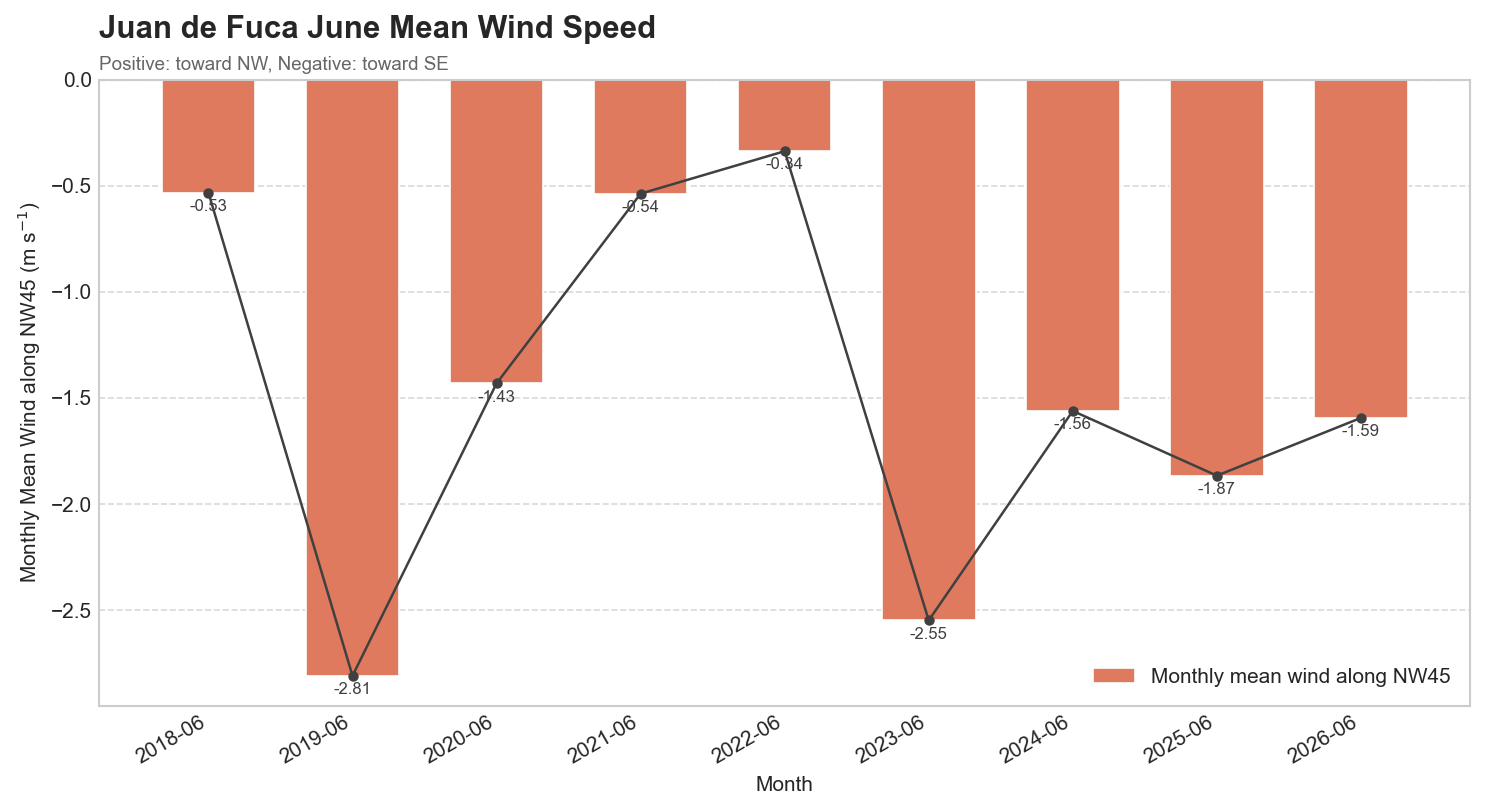

In [ ]:
# Monthly-mean Visualization


from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 文件路径
# -----------------------------------------------------------------------------

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_atmo_events"
)

CSV_PATHS = [
    DATA_DIR / "Data_hrdps_June_JdF_2018_2022.csv",
    DATA_DIR / "Data_hrdps_June_JdF_2023_2026.csv",
]

OUTPUT_CSV = DATA_DIR / "Data_hrdps_June_JdF_monthly_mean_2018_2026.csv"



# -----------------------------------------------------------------------------
# 数据读取
# -----------------------------------------------------------------------------

required_columns = {
    "time",
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_NW45",
    "wind_SE45",
}

wind_data = []

for csv_path in CSV_PATHS:

    if not csv_path.exists():
        raise FileNotFoundError(
            f"找不到 CSV 文件：{csv_path.resolve()}"
        )

    df = pd.read_csv(
        csv_path,
        parse_dates=["time"],
    )

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"文件 {csv_path.name} 缺少以下列："
            f"{sorted(missing_columns)}\n"
            f"现有列：{list(df.columns)}"
        )

    print(f"读取文件：{csv_path.name}")
    print(f"记录数：{len(df)}")
    print(f"时间范围：{df['time'].min()} 至 {df['time'].max()}")
    print()

    wind_data.append(df)


# 合并两个时期的数据
wind = pd.concat(
    wind_data,
    ignore_index=True,
)


# -----------------------------------------------------------------------------
# 数据清理
# -----------------------------------------------------------------------------

numeric_columns = [
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_NW45",
    "wind_SE45",
]

# 确保风速相关列均为数值型
for column in numeric_columns:
    wind[column] = pd.to_numeric(
        wind[column],
        errors="coerce",
    )

# 删除时间或 NW45 风速无效的记录
wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)

# 检查数据是否全部来自 6 月
non_june = wind.loc[wind["time"].dt.month != 6]

if not non_june.empty:
    print(
        f"警告：发现 {len(non_june)} 条非 6 月记录，"
        "这些记录将不会用于本次计算。"
    )

# 只保留 6 月
wind = wind.loc[wind["time"].dt.month == 6].copy()

print(f"合并并清理后的记录数：{len(wind)}")
print(f"起始时间：{wind['time'].min()}")
print(f"结束时间：{wind['time'].max()}")


# -----------------------------------------------------------------------------
# 计算每个月的平均值
# -----------------------------------------------------------------------------

# 转换成月份，例如 2018-06、2019-06
wind["month"] = wind["time"].dt.to_period("M")

monthly_mean = (
    wind.groupby("month", as_index=False)
    .agg(
        u_wind_mean=("u_wind", "mean"),
        v_wind_mean=("v_wind", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_NW45_mean=("wind_NW45", "mean"),
        wind_SE45_mean=("wind_SE45", "mean"),
        record_count=("time", "size"),
    )
    .sort_values("month")
    .reset_index(drop=True)
)

# Period 转换成时间戳，方便绘图和输出
monthly_mean["time"] = monthly_mean["month"].dt.to_timestamp()

# 增加文字标签，例如 2018-06
monthly_mean["month_label"] = monthly_mean["month"].astype(str)


# -----------------------------------------------------------------------------
# 输出月平均结果
# -----------------------------------------------------------------------------

print("\n每年 6 月平均风速：")
print(
    monthly_mean[
        [
            "month_label",
            "wind_NW45_mean",
            "wind_speed_mean",
            "record_count",
        ]
    ].to_string(
        index=False,
        formatters={
            "wind_NW45_mean": "{:.3f}".format,
            "wind_speed_mean": "{:.3f}".format,
        },
    )
)

# 保存月平均数据
output_columns = [
    "time",
    "month_label",
    "u_wind_mean",
    "v_wind_mean",
    "wind_speed_mean",
    "wind_NW45_mean",
    "wind_SE45_mean",
    "record_count",
]

monthly_mean[output_columns].to_csv(
    OUTPUT_CSV,
    index=False,
    float_format="%.6f",
)

print(f"\n月平均结果已保存至：{OUTPUT_CSV}")


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5),
    dpi=150,
)

x = np.arange(len(monthly_mean))
y = monthly_mean["wind_NW45_mean"]


# 根据正负值设置颜色
# 正值：风吹向 NW
# 负值：风吹向 SE
bar_colors = np.where(
    y >= 0,
    "#24a98b",
    "#e07a5f",
)

bars = ax.bar(
    x,
    y,
    width=0.65,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    label="Monthly mean wind along NW45",
)


# 将月平均值连接起来，便于观察年际变化
ax.plot(
    x,
    y,
    color="0.25",
    lw=1.2,
    marker="o",
    markersize=4,
    zorder=3,
)


# 零线：区分指向 NW 和指向 SE 的风
ax.axhline(
    0,
    color="0.25",
    lw=1,
    linestyle="--",
    alpha=0.8,
)


# 在柱子上标注数值
for bar, value in zip(bars, y):

    if value >= 0:
        vertical_alignment = "bottom"
        y_offset = 3
    else:
        vertical_alignment = "top"
        y_offset = -3

    ax.annotate(
        f"{value:.2f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            value,
        ),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=8,
        color="0.25",
    )


ax.set_xticks(x)
ax.set_xticklabels(
    monthly_mean["month_label"],
    rotation=30,
    ha="right",
)

ax.set_title(
    "Juan de Fuca June Mean Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly Mean Wind along NW45 (m s$^{-1}$)")

ax.grid(
    True,
    axis="y",
    alpha=0.75,
    linestyle="--",
)

ax.grid(
    False,
    axis="x",
)

ax.legend(
    loc="best",
    frameon=False,
)

# 如果希望固定纵坐标范围，可以取消下面这一行的注释
# ax.set_ylim(-10, 10)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()


plt.show()

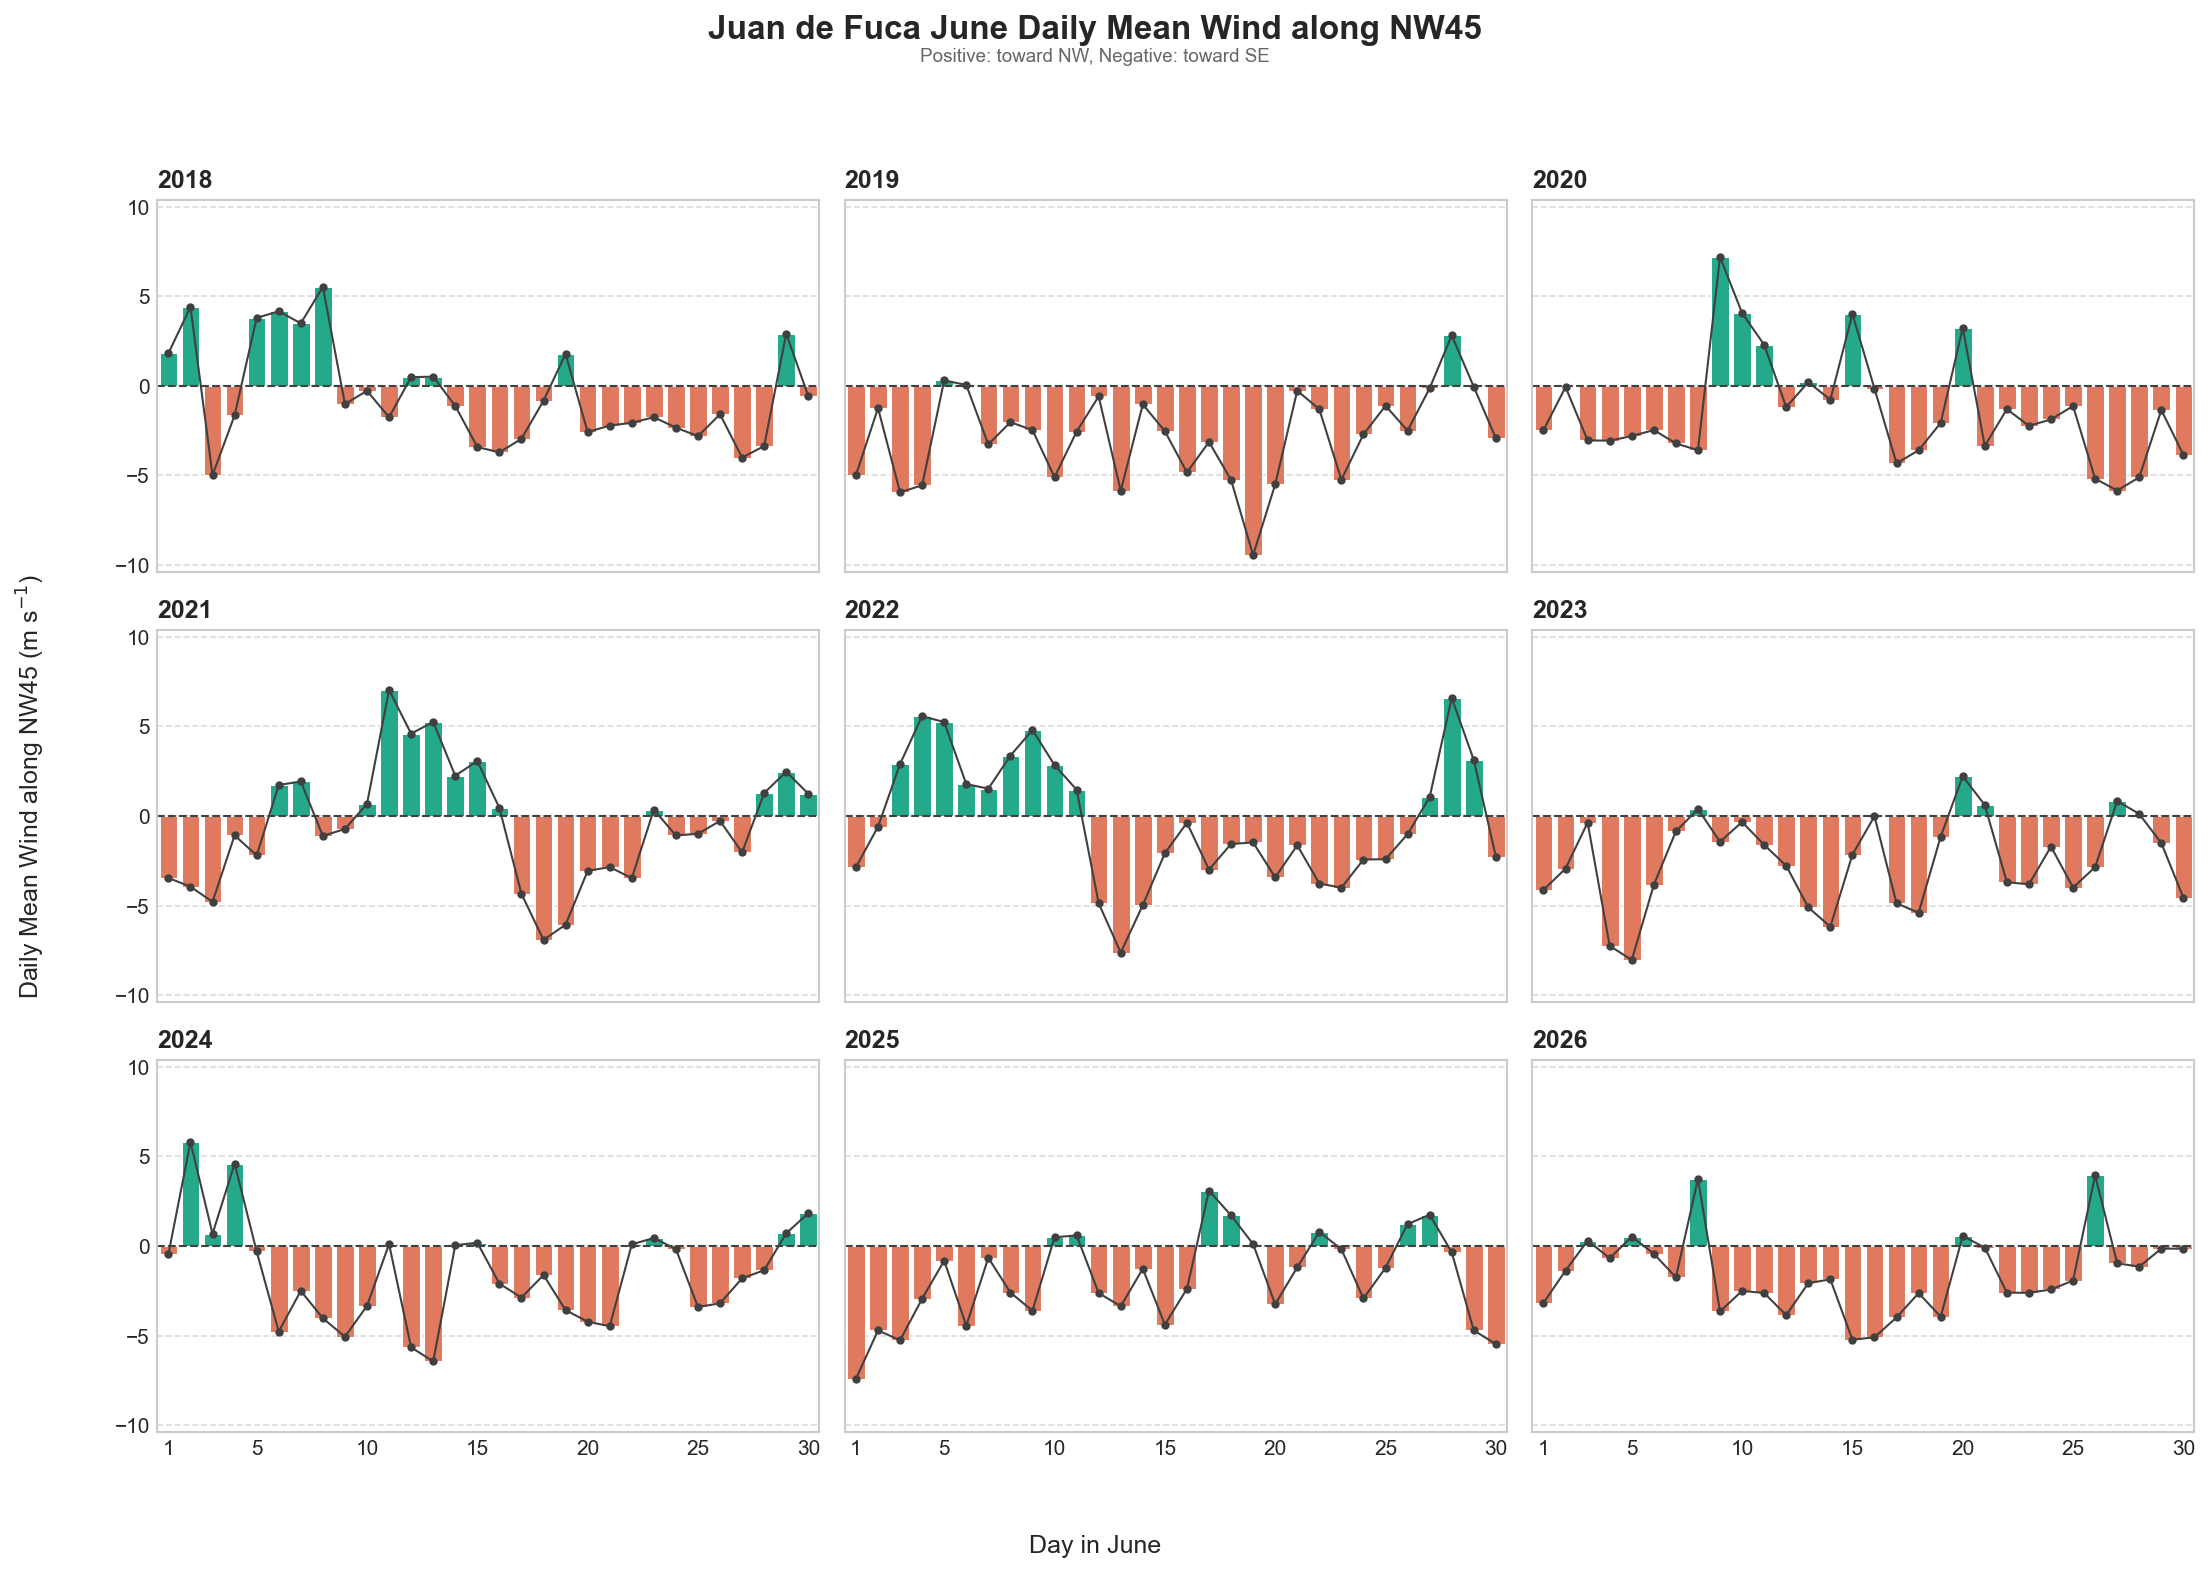

In [1]:
# Daily-mean Visualization

from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 文件路径
# -----------------------------------------------------------------------------

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_atmo_events"
)

CSV_PATHS = [
    DATA_DIR / "Data_hrdps_June_JdF_2018_2022.csv",
    DATA_DIR / "Data_hrdps_June_JdF_2023_2026.csv",
]


# -----------------------------------------------------------------------------
# 读取并合并数据
# -----------------------------------------------------------------------------

wind_data = []

for csv_path in CSV_PATHS:

    if not csv_path.exists():
        raise FileNotFoundError(
            f"找不到 CSV 文件：{csv_path.resolve()}"
        )

    df = pd.read_csv(
        csv_path,
        parse_dates=["time"],
    )

    wind_data.append(df)


wind = pd.concat(
    wind_data,
    ignore_index=True,
)


# -----------------------------------------------------------------------------
# 数据清理
# -----------------------------------------------------------------------------

numeric_columns = [
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_NW45",
    "wind_SE45",
]

for column in numeric_columns:
    wind[column] = pd.to_numeric(
        wind[column],
        errors="coerce",
    )


wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)


# 只保留 6 月数据
wind = wind.loc[
    wind["time"].dt.month == 6
].copy()


# -----------------------------------------------------------------------------
# 计算日平均
# -----------------------------------------------------------------------------

wind["date"] = wind["time"].dt.floor("D")


daily_mean = (
    wind.groupby("date", as_index=False)
    .agg(
        u_wind_mean=("u_wind", "mean"),
        v_wind_mean=("v_wind", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_NW45_mean=("wind_NW45", "mean"),
        wind_SE45_mean=("wind_SE45", "mean"),
    )
    .sort_values("date")
    .reset_index(drop=True)
)


daily_mean["year"] = daily_mean["date"].dt.year
daily_mean["day"] = daily_mean["date"].dt.day


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

years = sorted(
    daily_mean["year"].unique()
)

ncols = 3
nrows = math.ceil(len(years) / ncols)


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 3.5 * nrows),
    dpi=150,
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()


# 所有子图使用相同的纵坐标范围
max_abs_value = daily_mean["wind_NW45_mean"].abs().max()
y_limit = max(max_abs_value * 1.1, 1)


for ax, year in zip(axes, years):

    year_data = (
        daily_mean.loc[
            daily_mean["year"] == year
        ]
        .sort_values("date")
    )

    x = year_data["day"]
    y = year_data["wind_NW45_mean"]


    # 正值：吹向 NW
    # 负值：吹向 SE
    bar_colors = np.where(
        y >= 0,
        "#24a98b",
        "#e07a5f",
    )


    ax.bar(
        x,
        y,
        width=0.8,
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5,
    )


    ax.plot(
        x,
        y,
        color="0.25",
        linewidth=1,
        marker="o",
        markersize=3,
    )


    ax.axhline(
        0,
        color="0.25",
        linewidth=1,
        linestyle="--",
    )


    ax.set_title(
        str(year),
        loc="left",
        fontsize=12,
        fontweight="bold",
    )


    ax.set_xlim(0.5, 30.5)
    ax.set_ylim(-y_limit, y_limit)

    ax.set_xticks(
        [1, 5, 10, 15, 20, 25, 30]
    )


    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.7,
    )

    ax.grid(
        False,
        axis="x",
    )


# 删除多余的空子图
for ax in axes[len(years):]:
    ax.remove()


fig.suptitle(
    "Juan de Fuca June Daily Mean Wind along NW45",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

fig.text(
    0.5,
    0.96,
    "Positive: toward NW, Negative: toward SE",
    ha="center",
    fontsize=9,
    color="0.4",
)

fig.supxlabel("Day in June")

fig.supylabel(
    "Daily Mean Wind along NW45 (m s$^{-1}$)"
)

fig.tight_layout(
    rect=[0.03, 0.03, 1, 0.94]
)

plt.show()